## *Assignment 2:* `Data Quality Assessment & Preprocessing` 🧹

*In real-world machine learning projects, data is often:*

#### `Incomplete` *(missing values)* ❌

#### `Noisy` *(outliers or random errors)* ⚠️

#### `Inconsistent` *(wrong formats, mixed units)* 🔄

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](images/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

### 1. Importing the Libraries  📚

In [172]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## `Task 1: Data Quality Assessment` 🔍


### ✦ Load Dataset 📥


In [173]:
df = pd.read_csv("Super_Store.csv")
print("Shape:", df.shape)
df.head()

Shape: (9800, 18)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


### ✦ Check Data Types 📊


In [174]:
print(df.dtypes)

Row_ID             int64
Order_ID             str
Order_Date           str
Ship_Date            str
Ship_Mode            str
Customer_ID          str
Customer_Name        str
Segment              str
Country              str
City                 str
State                str
Postal_Code      float64
Region               str
Product_ID           str
Category             str
Sub_Category         str
Product_Name         str
Sales            float64
dtype: object


### ✦ Check Missing Values ❌

In [175]:
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

Duplicates: 0


### ✦ Statistical Summary 📈


In [176]:
df.describe()


,Row_ID,Postal_Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


### ✦ Visualize Missing Data 📉

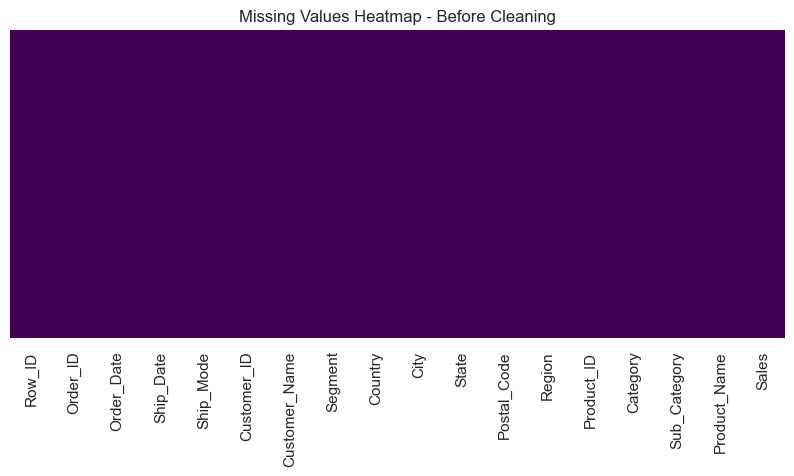

In [177]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap - Before Cleaning')
plt.show()


### ✦ Boxplot for Outliers 📦

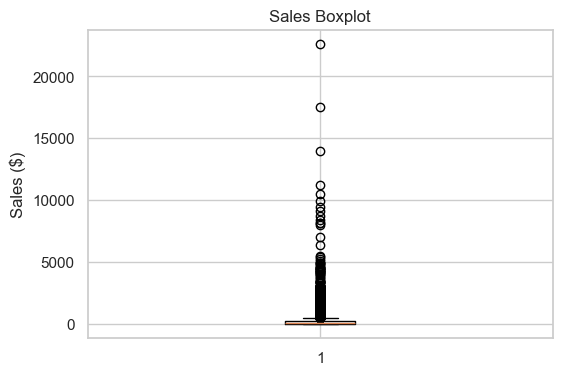

In [178]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['Sales'].dropna())
plt.title('Sales Boxplot')
plt.ylabel('Sales ($)')
plt.show()

## `Task 2: Handling Missing Values` 🛠️


### Fix Data Types 🔧

In [216]:
df_clean = df.copy()

df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], dayfirst=True, errors='coerce')
df_clean['Ship_Date'] = pd.to_datetime(df_clean['Ship_Date'], dayfirst=True, errors='coerce')

print("Missing values after conversion:")
print(df_clean[['Order_Date', 'Ship_Date']].isnull().sum())

Missing values after conversion:
Order_Date    0
Ship_Date     0
dtype: int64


#### `Mean` Formula 📊

![Mean.png](images/Mean.png)

#### `Median` Formula 📊

![median.png](images/median.png)

#### `Median` Formula (*Detailed*) 📊

![median_formula_2.png](images/median_formula_2.png)

 ### Remove Missing Dates 🗑️

In [217]:
print("Rows before:", len(df_clean))
print("Missing Order_Date:", df_clean['Order_Date'].isnull().sum())

# Remove rows with missing Order_Date
df_clean = df_clean.dropna(subset=['Order_Date']).copy()

print("\nRows after:", len(df_clean))
print("Missing Order_Date now:", df_clean['Order_Date'].isnull().sum())
print(f"Rows removed: {9800 - len(df_clean)}")

Rows before: 9800
Missing Order_Date: 0

Rows after: 9800
Missing Order_Date now: 0
Rows removed: 0


 ### Verify Clean Data ✅


In [218]:
print("Total missing values in entire dataset:", df_clean.isnull().sum().sum())
df_clean.head()

Total missing values in entire dataset: 11


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


 ### Fill Remaining Missing Values `(Postal_Code)` 📝


In [219]:
# Fill missing Postal_Code with 'Unknown'
df_clean['Postal_Code'] = df_clean['Postal_Code'].fillna('Unknown').astype(str)

print("Missing values after fixing:")
print(df_clean.isnull().sum())
print(f"\nTotal missing values now: {df_clean.isnull().sum().sum()}")

Missing values after fixing:
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub_Category     0
Product_Name     0
Sales            0
dtype: int64

Total missing values now: 0


### Verify Clean Data ✅


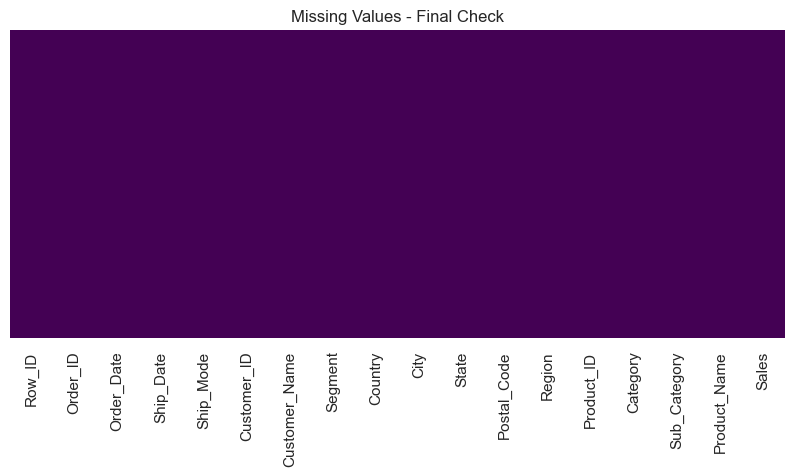

Dataset is clean!


In [220]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values - Final Check')
plt.show()

print("Dataset is clean!" if df_clean.isnull().sum().sum() == 0 else "Still have missing values")

## `Task 3: Detecting and Handling Outliers` ⚠️


#### IQR Method for Outliers 📐

![IQR.png](images/IQR.png)

### Detect Outliers Using IQR Method 📐

In [212]:
Q1 = df_clean['Sales'].quantile(0.25)
Q3 = df_clean['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['Sales'] < lower) | (df_clean['Sales'] > upper)]

print(f"Q1: ${Q1:.2f}")
print(f"Q3: ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower:.2f}")
print(f"Upper bound: ${upper:.2f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

Q1: $17.25
Q3: $210.61
IQR: $193.36
Lower bound: $-272.79
Upper bound: $500.64
Outliers: 1145 (11.68%)


### Visualize Outliers 📊

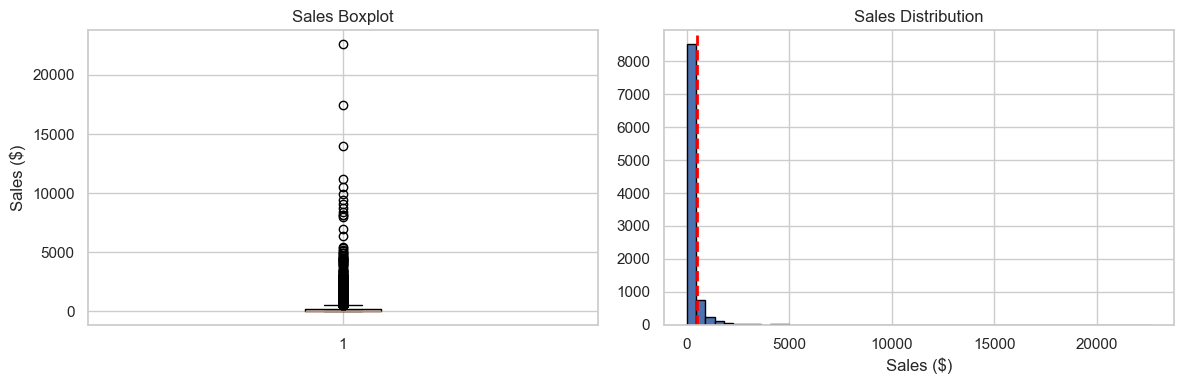

In [213]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.boxplot(df_clean['Sales'])
ax1.set_title('Sales Boxplot')
ax1.set_ylabel('Sales ($)')

ax2.hist(df_clean['Sales'], bins=50, edgecolor='black')
ax2.axvline(upper, color='red', linestyle='--', linewidth=2)
ax2.set_title('Sales Distribution')
ax2.set_xlabel('Sales ($)')

plt.tight_layout()
plt.show()

### Remove Outliers 🗑️


In [214]:
df_no_outliers = df_clean[(df_clean['Sales'] >= lower) & (df_clean['Sales'] <= upper)].copy()

print(f"Before removing outliers: {len(df_clean)} rows")
print(f"After removing outliers: {len(df_no_outliers)} rows")
print(f"Rows removed: {len(df_clean) - len(df_no_outliers)}")

Before removing outliers: 9800 rows
After removing outliers: 8655 rows
Rows removed: 1145


### Compare Before and After 📈

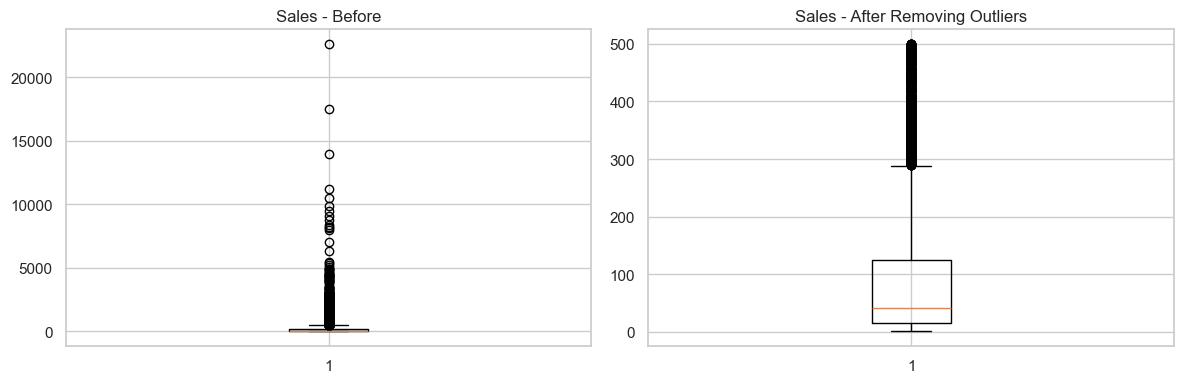

STATISTICAL COMPARISON:
Before - Mean: $230.77, Std: $626.65
After  - Mean: $93.21, Std: $114.69


In [215]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.boxplot(df_clean['Sales'])
ax1.set_title('Sales - Before')

ax2.boxplot(df_no_outliers['Sales'])
ax2.set_title('Sales - After Removing Outliers')

plt.tight_layout()
plt.show()

print("STATISTICAL COMPARISON:")
print(f"Before - Mean: ${df_clean['Sales'].mean():.2f}, Std: ${df_clean['Sales'].std():.2f}")
print(f"After  - Mean: ${df_no_outliers['Sales'].mean():.2f}, Std: ${df_no_outliers['Sales'].std():.2f}")

## `Task 4: Data Normalization` 📏

### Original Sales Data 💰


In [221]:
sales = df_no_outliers[['Sales']].copy()
print("Original Sales (first 10 rows):")
sales.head(10)

Original Sales (first 10 rows):


,Sales
0,261.960
2,14.620
4,22.368
5,48.860
6,7.280
8,18.504
9,114.900
12,15.552
13,407.976
14,68.810


#### Min-Max Normalization Formula 🔢

![min_max.png](images/min_max.png)

### Min-Max Normalization (0 to 1) 🔢


In [222]:
min_val = sales['Sales'].min()
max_val = sales['Sales'].max()
print(f"Min: ${min_val:.2f}, Max: ${max_val:.2f}")

sales_minmax = (sales['Sales'] - min_val) / (max_val - min_val)

print("\nMin-Max Normalized (first 10 rows):")
print(sales_minmax.head(10))
print(f"\nMin: {sales_minmax.min():.4f}, Max: {sales_minmax.max():.4f}")

Min: $0.44, Max: $500.24

Min-Max Normalized (first 10 rows):
0     0.523245
2     0.028364
4     0.043866
5     0.096872
6     0.013678
8     0.036135
9     0.229005
12    0.030228
13    0.815397
14    0.136788
Name: Sales, dtype: float64

Min: 0.0000, Max: 1.0000


#### Percentile Formula for Capping 🎯

![percentile.png](images/percentile.png)

### Z-Score Normalization `(Mean=0, Std=1)` 📊


In [223]:
mean_val = sales['Sales'].mean()
std_val = sales['Sales'].std()
print(f"Mean: ${mean_val:.2f}, Std: ${std_val:.2f}")

sales_zscore = (sales['Sales'] - mean_val) / std_val

print("\nZ-Score Normalized (first 10 rows):")
print(sales_zscore.head(10))
print(f"\nMean: {sales_zscore.mean():.4f}, Std: {sales_zscore.std():.4f}")

Mean: $93.21, Std: $114.69

Z-Score Normalized (first 10 rows):
0     1.471286
2    -0.685248
4    -0.617694
5    -0.386713
6    -0.749245
8    -0.651384
9     0.189084
12   -0.677122
13    2.744386
14   -0.212770
Name: Sales, dtype: float64

Mean: 0.0000, Std: 1.0000


### Visualize All Three 📊


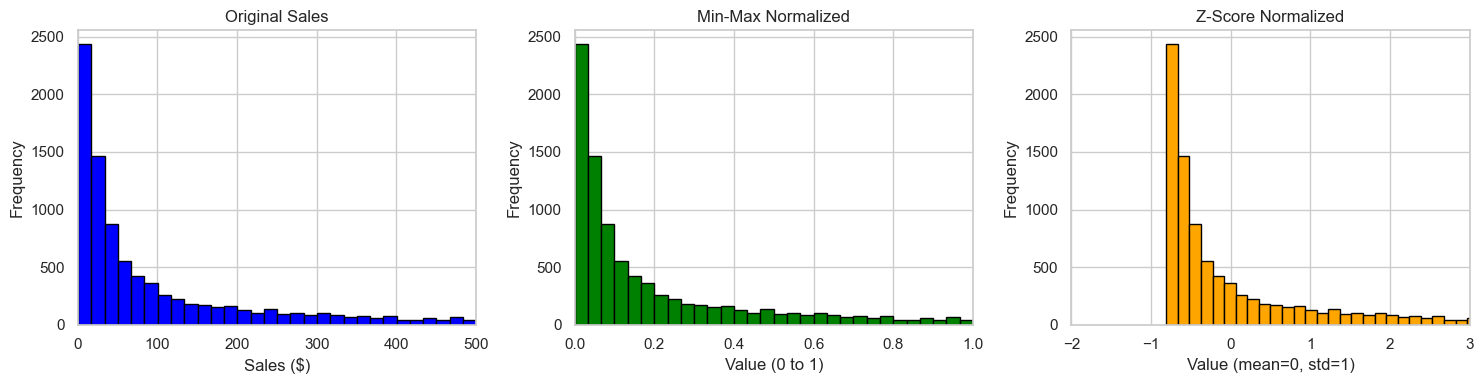

Original Sales range: 0.444 to 500.24
Min-Max range: 0.0 to 1.0
Z-Score range: -0.8088470389641882 to 3.548827155361156


In [224]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
axes[0].hist(sales['Sales'], bins=30, edgecolor='black', color='blue')
axes[0].set_title('Original Sales')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 500)  # Limit x-axis to see distribution better

# Min-Max
axes[1].hist(sales_minmax, bins=30, edgecolor='black', color='green')
axes[1].set_title('Min-Max Normalized')
axes[1].set_xlabel('Value (0 to 1)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1)

# Z-Score
axes[2].hist(sales_zscore, bins=30, edgecolor='black', color='orange')
axes[2].set_title('Z-Score Normalized')
axes[2].set_xlabel('Value (mean=0, std=1)')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(-2, 3)

plt.tight_layout()
plt.show()

# Print actual ranges to verify
print("Original Sales range:", sales['Sales'].min(), "to", sales['Sales'].max())
print("Min-Max range:", sales_minmax.min(), "to", sales_minmax.max()) 
print("Z-Score range:", sales_zscore.min(), "to", sales_zscore.max())

## `Task 5: Principal Component Analysis (PCA)` 📉


### Create Simple Features for PCA 🔨


In [192]:
df_pca = df_no_outliers.copy()

# Create simple derived features
df_pca['Sales2'] = df_pca['Sales'] * 2
df_pca['Sales_half'] = df_pca['Sales'] / 2
df_pca['Sales_sq'] = df_pca['Sales'] ** 2

features = ['Sales', 'Sales2', 'Sales_half', 'Sales_sq']
X = df_pca[features].copy()
print("Features for PCA:")
X.head()

Features for PCA:


,Sales,Sales2,Sales_half,Sales_sq
0,261.960,523.920,130.980,68623.041600
2,14.620,29.240,7.310,213.744400
4,22.368,44.736,11.184,500.327424
5,48.860,97.720,24.430,2387.299600
6,7.280,14.560,3.640,52.998400


### Standardize the Data 📐


In [193]:
X_scaled = X.copy()
for col in features:
    X_scaled[col] = (X[col] - X[col].mean()) / X[col].std()

print("Standardized data (first 5 rows):")
X_scaled.head()

Standardized data (first 5 rows):


,Sales,Sales2,Sales_half,Sales_sq
0,1.471286,1.471286,1.471286,1.018592
2,-0.685248,-0.685248,-0.685248,-0.470917
4,-0.617694,-0.617694,-0.617694,-0.464677
5,-0.386713,-0.386713,-0.386713,-0.423591
6,-0.749245,-0.749245,-0.749245,-0.474417


### Check Correlation Matrix 🔗


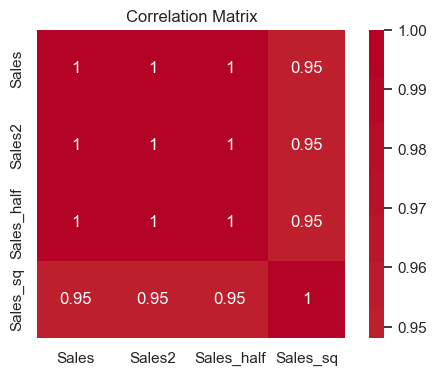

In [194]:
plt.figure(figsize=(6, 4))
sns.heatmap(X_scaled.corr(), annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix')
plt.show()

### Manual PCA Calculation 🧮

In [195]:
# Calculate covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by eigenvalues (largest first)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calculate explained variance
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

print("EXPLAINED VARIANCE:")
for i, (ev, cum) in enumerate(zip(explained_variance, cumulative_variance)):
    print(f"PC{i+1}: {ev:.2%} - Cumulative: {cum:.2%}")

EXPLAINED VARIANCE:
PC1: 98.07% - Cumulative: 98.07%
PC2: 1.93% - Cumulative: 100.00%
PC3: 0.00% - Cumulative: 100.00%
PC4: -0.00% - Cumulative: 100.00%


### Scree Plot 📊


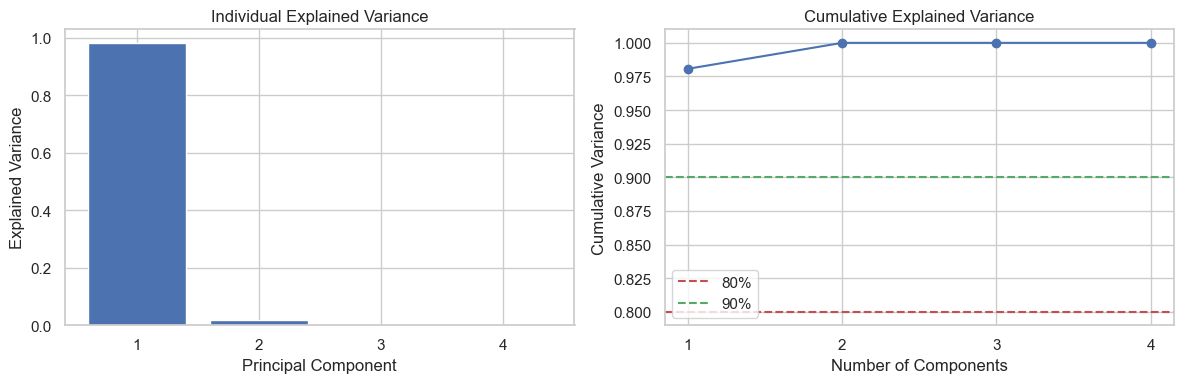

In [196]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(1, 5), explained_variance)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance')
plt.title('Individual Explained Variance')
plt.xticks(range(1, 5))

plt.subplot(1, 2, 2)
plt.plot(range(1, 5), cumulative_variance, 'bo-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.9, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.xticks(range(1, 5))

plt.tight_layout()
plt.show()

### Get First 2 Principal Components 📊


In [197]:
# Use first 2 components
n_components = 2
principal_components = X_scaled.values @ eigenvectors[:, :n_components]

pc_df = pd.DataFrame(
    principal_components, 
    columns=[f'PC{i+1}' for i in range(n_components)]
)

print("First 10 rows of Principal Components:")
pc_df.head(10)

First 10 rows of Principal Components:


,PC1,PC2
0,-2.720619,0.360294
1,1.265412,-0.170848
2,1.160348,-0.118972
3,0.791437,0.041185
4,1.363762,-0.222094
5,1.212904,-0.144558
6,-0.193370,0.324430
7,1.252842,-0.164487
8,-5.686355,-0.416419
9,0.503744,0.144204


### Visualize PCA Projection 📈


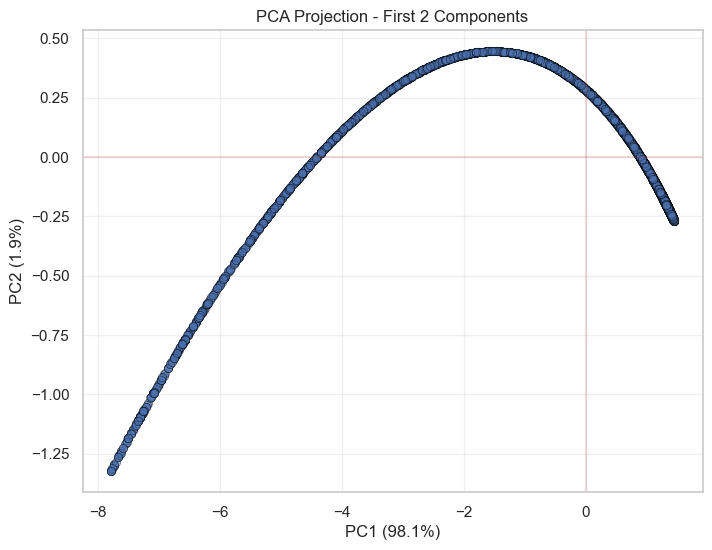

In [198]:
plt.figure(figsize=(8, 6))
plt.scatter(pc_df['PC1'], pc_df['PC2'], alpha=0.5, edgecolors='black', linewidth=0.5)
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})')
plt.title('PCA Projection - First 2 Components')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.2)
plt.show()

### PCA Summary 📝


In [199]:
print("="*50)
print("PCA RESULTS SUMMARY")
print("="*50)
print(f"Original features: 4")
print(f"Components selected: 2")
print(f"Variance retained: {cumulative_variance[1]*100:.1f}%")
print(f"Variance lost: {(1-cumulative_variance[1])*100:.1f}%")
print("\nPC1 explains:", f"{explained_variance[0]:.1%}")
print("PC2 explains:", f"{explained_variance[1]:.1%}")

PCA RESULTS SUMMARY
Original features: 4
Components selected: 2
Variance retained: 100.0%
Variance lost: 0.0%

PC1 explains: 98.1%
PC2 explains: 1.9%


## Formulas Summary 📚


### `Mean`
![Mean.png](images/Mean.png)

### `Median`
![median.png](images/median.png)


### `Median (Detailed)`

![median_formula_2.png](images/median_formula_2.png)

### `IQR Outlier Detection`
![IQR.png](images/IQR.png)

### `Percentile Calculation`
![percentile.png](images/percentile.png)

### `Min-Max Normalization`
![min_max.png](images/min_max.png)